# FZI-AURA - Annotations, Calibration, and Projection

This notebook covers supported label and calibration workflows:

- 3D boxes on sparse keyframes
- semantic lidar labels paired with motion-compensated lidar
- camera projection and sensor transforms

Metadata and annotations require `base_keyframes`. Detection and semantic arrays use `lidar_motion_compensated_keyframes`; camera projection additionally uses `camera_keyframes`. Camera-only cells are skipped when that layer is not installed.


In [ ]:
# If fzi_aura or the plotting dependencies are not available in this notebook's current Python kernel,
# uncomment and run the next line before continuing. %pip targets this kernel.
# %pip install "fzi-aura[vis]"

In [1]:
import os
from pathlib import Path

import numpy as np

from fzi_aura import FZIAURADataset

os.environ["FZI_AURA_ROOT"] = "/data/fzi-aura"

DATASET_ROOT = Path(
    os.environ.get(
        "FZI_AURA_ROOT",
        "/path/to/dataset_export",
    )
)

dataset = FZIAURADataset(DATASET_ROOT, split="train")
scene = dataset[-1]


def layer_installed(layer):
    return dataset.available_layers is None or layer in dataset.available_layers


lidar_keyframes_installed = layer_installed("lidar_motion_compensated_keyframes")
camera_keyframes_installed = layer_installed("camera_keyframes")
print(f"Scenes: {len(dataset)}")

Scenes: 1979


## 1. Load a 3D Box Keyframe

In [2]:
box_frames = scene.frames(
    sample_filter="boxes_3d",
    require_lidars=["top_left"],
)
frame = box_frames[20] if len(box_frames) else None
boxes = None
camera_id = None
lidar_id = "top_left"

if frame is None:
    print("Skipped: lidar_motion_compensated_keyframes is required.")
else:
    boxes = frame.load_boxes(frame="base_link")
    if camera_keyframes_installed and frame.has_camera("front_medium"):
        camera_id = "front_medium"
    print(
        f"Frame: scene={frame.scene_id}, frame_index={frame.frame_index}, timestamp={frame.timestamp_ns}"
    )
    print(f"Boxes: {len(boxes)}")
    if len(boxes):
        box = boxes.boxes[0]
        print(f"box category: {box.category}")
        print(f"scene unique id: {box.object_id}")
        print("center:", box.center)
        print("size_lwh:", box.size_lwh)
        print("corners:", box.corners().shape)

Frame: scene=2026-06-03-09-57-03|98, frame_index=100, timestamp=1780482739200000000
Boxes: 16
box category: person
scene unique id: person:2
center: [47.69156074 -9.11288168  2.43344318]
size_lwh: [0.88960094 0.87270292 1.68435143]
corners: (8, 3)


## 2. Prepare Detection Arrays

The SDK returns NumPy arrays. This example shows one possible assembly with a stable detection-class order and the point features `x`, `y`, `z`, and raw `reflectivity`. Points and boxes are expressed in `base_link`. String categories and object IDs are retained for inspection, tracking, and evaluation. Annotated keyframes with zero boxes are valid and produce arrays with zero rows.

In [3]:
from fzi_aura import DETECTION_CLASSES

category_to_id = {name: index for index, name in enumerate(DETECTION_CLASSES)}
detection_arrays = None

if frame is None:
    print("Skipped: lidar_motion_compensated_keyframes is required.")
else:
    cloud = frame.load_lidar(lidar_id, stage="motion_compensated")
    if not cloud.has_field("reflectivity"):
        raise RuntimeError(
            f"{lidar_id} does not provide the configured reflectivity feature"
        )

    points_base = frame.calibration().transform_points(
        cloud.xyz,
        dst_frame="base_link",
        src_frame=f"lidar/{lidar_id}",
    )
    point_features = np.column_stack([points_base, cloud.field("reflectivity")]).astype(
        np.float32
    )

    box_arrays = boxes.as_numpy()
    unknown_categories = sorted(set(box_arrays["category"]) - set(category_to_id))
    if unknown_categories:
        raise ValueError(
            f"Categories missing from DETECTION_CLASSES: {unknown_categories}"
        )
    box_class_ids = np.asarray(
        [category_to_id[name] for name in box_arrays["category"]],
        dtype=np.int64,
    )
    box_targets_7d = np.column_stack(
        [box_arrays["center"], box_arrays["size_lwh"], box_arrays["yaw"]]
    ).astype(np.float32)

    detection_arrays = {
        "scene_id": frame.scene_id,
        "frame_index": frame.frame_index,
        "timestamp_ns": frame.timestamp_ns,
        "coordinate_frame": "base_link",
        "point_feature_names": ("x", "y", "z", "reflectivity"),
        "point_features": point_features,
        "box_targets_7d": box_targets_7d,
        "box_quaternions_xyzw": box_arrays["rotation_xyzw"].astype(np.float32),
        "box_class_ids": box_class_ids,
        "box_class_names": box_arrays["category"],
        "box_object_ids": box_arrays["object_id"],
    }
    print(
        {
            key: value.shape
            for key, value in detection_arrays.items()
            if isinstance(value, np.ndarray)
        }
    )

{'point_features': (77016, 4), 'box_targets_7d': (16, 7), 'box_quaternions_xyzw': (16, 4), 'box_class_ids': (16,), 'box_class_names': (16,), 'box_object_ids': (16,)}


## 3. Calibration

In [4]:
if frame is None:
    print("Skipped: a LiDAR box keyframe is required.")
else:
    calib = frame.calibration()
    print("Cameras:", calib.sensor_ids("camera"))
    print("Lidars:", calib.sensor_ids("lidar"))

    base_from_lidar = calib.base_from_sensor(f"lidar/{lidar_id}")
    print("base_from_lidar:", base_from_lidar.shape)

    if camera_id is None:
        print("Camera calibration example skipped: camera_keyframes is not installed.")
    else:
        P = calib.camera_projection_matrix(camera_id)
        camera_from_base = calib.sensor_from_base(f"camera/{camera_id}")
        print("P:", P.shape)
        print("camera_from_base:", camera_from_base.shape)

Cameras: ('front_medium', 'front_tele', 'front_wide', 'left_forward', 'left_rearward', 'rear_wide', 'right_forward', 'right_rearward')
Lidars: ('aeva_front_center', 'aeva_front_left', 'aeva_front_right', 'aeva_rear_center', 'aeva_side_left', 'aeva_side_right', 'front_left', 'front_right', 'rear_left', 'rear_right', 'top_left', 'top_right')
base_from_lidar: (4, 4)
P: (3, 4)
camera_from_base: (4, 4)


## 4. Project 3D Boxes Into a Camera

In [5]:
image = None
projected_boxes = []
if camera_id is None:
    print("Skipped: camera_keyframes is required for camera projection.")
else:
    image = frame.load_camera(camera_id)
    height, width = image.shape[:2]
    projected_boxes = frame.project_boxes_to_camera(camera_id, boxes=boxes)
    print(f"Projected boxes: {len(projected_boxes)}")

Projected boxes: 16


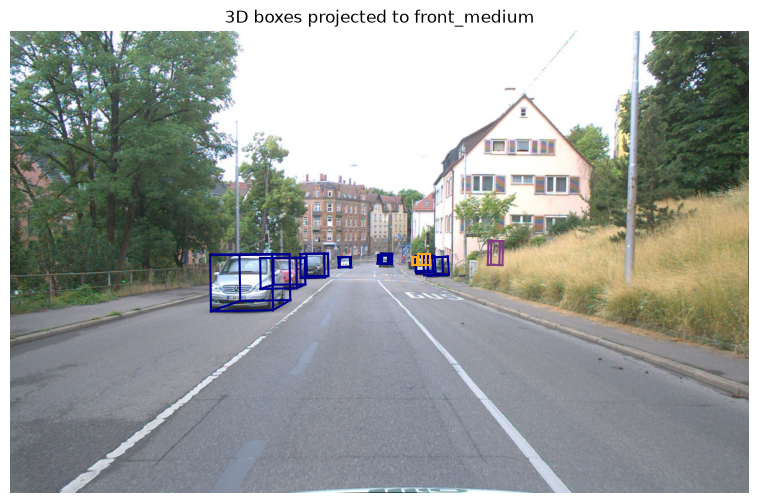

In [ ]:
import matplotlib.pyplot as plt


def matplotlib_color(category: str) -> tuple[float, float, float]:
    from fzi_aura.boxes import DETECTION_COLORS_UINT8

    rgb = DETECTION_COLORS_UINT8.get(category, (255, 255, 255))
    return tuple(channel / 255.0 for channel in rgb)


if image is not None:
    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    for item in projected_boxes:
        uv_box = item["uv"].astype(int)
        for start, end in item["visible_edges"]:
            plt.plot(
                [uv_box[start, 0], uv_box[end, 0]],
                [uv_box[start, 1], uv_box[end, 1]],
                color=matplotlib_color(item["box"].category),
                linewidth=1.5,
            )
    plt.title(f"3D boxes projected to {camera_id}")
    plt.xlim(0, width)
    plt.ylim(height, 0)
    plt.axis("off")
    plt.show()

## 5. Semantic Lidar Labels

`load_lidar_semantic_pair` accepts one sensor ID and loads point-aligned semantic and instance IDs with the motion-compensated LiDAR cloud. The example below keeps the four sensor IDs in a list and loops over them. Semantic ID `0` is named `unlabeled`; whether it is ignored, remapped, or retained is a downstream training and evaluation choice.

In [7]:
semantic_sensor_ids = ["top_left", "top_right", "front_left", "rear_right"]

# if the selected scene in your dataset does not contain semantic LiDAR data, you can select a different scene by filtering for scenes or frames with Semantic Lidar data.

# semantic_frames = dataset.as_frames(
#    sample_filter="semantic_lidar",
#    require_lidars=semantic_sensor_ids,
#    require_semantics_for=semantic_sensor_ids,
# )
semantic_frames = scene.frames(
    sample_filter="semantic_lidar",
    require_lidars=semantic_sensor_ids,
    require_semantics_for=semantic_sensor_ids,
)
print(f"Semantic frames: {len(semantic_frames)}")
semantic_arrays = None
semantic_pairs = {}

if len(semantic_frames):
    sem_frame = semantic_frames[20] if len(semantic_frames) else semantic_frames[0]
    sem_camera_id = (
        "front_medium"
        if camera_keyframes_installed and sem_frame.has_camera("front_medium")
        else None
    )
    semantic_arrays = {}
    for sensor_id in semantic_sensor_ids:
        sem_cloud, labels = sem_frame.load_lidar_semantic_pair(sensor_id)
        semantic_pairs[sensor_id] = (sem_cloud, labels)
        print(
            f"scene={sem_frame.scene_id}, frame={sem_frame.frame_index}, "
            f"sensor={sensor_id}, points={len(sem_cloud):,}, labels={len(labels):,}"
        )
        unique_ids = np.unique(labels.semantic_id)
        print("  semantic ids:", unique_ids[:20])
        if labels.class_names:
            print(
                "  classes:",
                {int(i): labels.class_names.get(int(i), "?") for i in unique_ids[:10]},
            )

        points_base = sem_frame.calibration().transform_points(
            sem_cloud.xyz,
            dst_frame="base_link",
            src_frame=f"lidar/{sensor_id}",
        )
        semantic_feature_names = ["x", "y", "z"]
        semantic_features = points_base.astype(np.float32)
        if sem_cloud.has_field("reflectivity"):
            semantic_feature_names.append("reflectivity")
            semantic_features = np.column_stack(
                [semantic_features, sem_cloud.field("reflectivity")]
            ).astype(np.float32)
        semantic_arrays[sensor_id] = {
            "coordinate_frame": "base_link",
            "point_feature_names": tuple(semantic_feature_names),
            "point_features": semantic_features,
            "semantic_id": labels.semantic_id.astype(np.int64),
            "instance_id": labels.instance_id.astype(np.int64),
        }
        class_ids, class_counts = np.unique(labels.semantic_id, return_counts=True)
        print(
            "  array shapes:",
            {
                key: value.shape
                for key, value in semantic_arrays[sensor_id].items()
                if isinstance(value, np.ndarray)
            },
        )
        print(
            "  per-class point counts:",
            dict(zip(class_ids.tolist(), class_counts.tolist())),
        )
    print("Loaded semantic LiDAR sensors:", tuple(semantic_pairs))
else:
    print("Skipped: the requested semantic LiDAR data is not available.")

Semantic frames: 40
scene=2026-06-03-09-57-03|98, frame=100, sensor=top_left, points=77,016, labels=77,016
  semantic ids: [ 1  2  5  7 16 17 18 19 22 23 24 25 27 29 30 31]
  classes: {1: 'road', 2: 'sidewalk', 5: 'person', 7: 'car', 16: 'building', 17: 'wall', 18: 'fence', 19: 'guard rail', 22: 'pole', 23: 'traffic sign'}
  array shapes: {'point_features': (77016, 4), 'semantic_id': (77016,), 'instance_id': (77016,)}
  per-class point counts: {1: 10641, 2: 4560, 5: 51, 7: 4440, 16: 10279, 17: 2378, 18: 2641, 19: 58, 22: 677, 23: 35, 24: 28, 25: 40645, 27: 405, 29: 9, 30: 44, 31: 125}
scene=2026-06-03-09-57-03|98, frame=100, sensor=top_right, points=80,245, labels=80,245
  semantic ids: [ 1  2  5  7 16 17 18 19 22 23 24 25 27 29 30 31]
  classes: {1: 'road', 2: 'sidewalk', 5: 'person', 7: 'car', 16: 'building', 17: 'wall', 18: 'fence', 19: 'guard rail', 22: 'pole', 23: 'traffic sign'}
  array shapes: {'point_features': (80245, 4), 'semantic_id': (80245,), 'instance_id': (80245,)}
  per

### Inspect Point-Level Instance IDs

`load_lidar_semantic_pair(...)` returns point-aligned semantic and instance IDs. Instance ID `0` means that a point is not assigned to an annotated object; nonzero values group points belonging to the same object instance.

In [8]:
instance_sensor_id = semantic_sensor_ids[0]
instance_cloud = None
instance_labels = None
instance_ids = np.empty(0, dtype=np.uint32)
valid_instance = np.empty(0, dtype=bool)

if len(semantic_frames):
    # Loaded above with sem_frame.load_lidar_semantic_pair(instance_sensor_id).
    instance_cloud, instance_labels = semantic_pairs[instance_sensor_id]
    valid_instance = instance_labels.instance_id != 0
    instance_ids = np.unique(instance_labels.instance_id[valid_instance])

    print(
        {
            "sensor": instance_sensor_id,
            "points": len(instance_cloud),
            "points_with_instance": int(valid_instance.sum()),
            "instances": len(instance_ids),
            "first_instance_ids": instance_ids[:10],
        }
    )
else:
    print("Skipped: semantic LiDAR labels are not available.")

{'sensor': 'top_left', 'points': 77016, 'points_with_instance': 4491, 'instances': 13, 'first_instance_ids': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=uint32)}


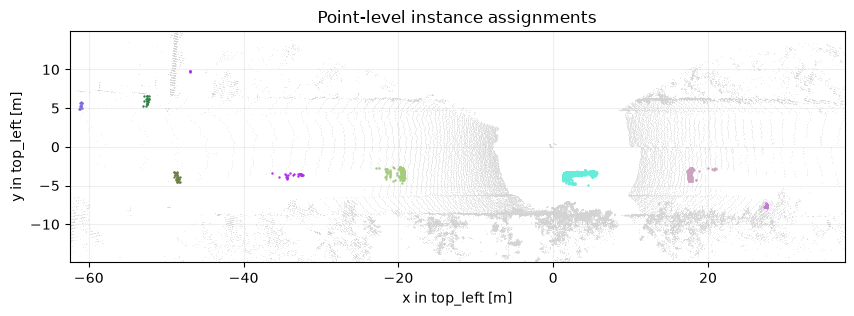

In [9]:
if instance_cloud is not None:
    rng = np.random.default_rng(42)
    instance_colors = {
        int(instance_id): rng.uniform(0.1, 0.95, size=3) for instance_id in instance_ids
    }
    instance_xy = instance_cloud.xyz[valid_instance, :2]
    lower = np.quantile(instance_xy, 0.01, axis=0) - 10.0
    upper = np.quantile(instance_xy, 0.99, axis=0) + 10.0
    context = (
        (instance_cloud.xyz[:, 0] >= lower[0])
        & (instance_cloud.xyz[:, 0] <= upper[0])
        & (instance_cloud.xyz[:, 1] >= lower[1])
        & (instance_cloud.xyz[:, 1] <= upper[1])
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        instance_cloud.xyz[context, 0],
        instance_cloud.xyz[context, 1],
        s=0.15,
        color="lightgray",
        linewidths=0,
    )
    for instance_id, color in instance_colors.items():
        points = instance_cloud.xyz[instance_labels.instance_id == instance_id]
        ax.scatter(
            points[:, 0],
            points[:, 1],
            s=3.0,
            color=color,
            linewidths=0,
        )

    ax.set_xlim(lower[0], upper[0])
    ax.set_ylim(lower[1], upper[1])
    ax.set_aspect("equal")
    ax.set_xlabel(f"x in {instance_sensor_id} [m]")
    ax.set_ylabel(f"y in {instance_sensor_id} [m]")
    ax.set_title("Point-level instance assignments")
    ax.grid(True, alpha=0.2)
    plt.show()

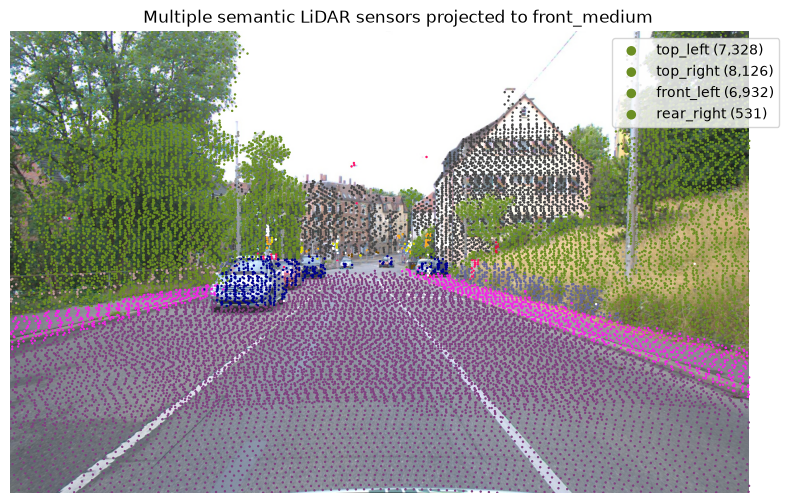

Projected semantic points inside image:
  top_left: 7,328
  top_right: 8,126
  front_left: 6,932
  rear_right: 531


In [10]:
semantic_projections = {}
if len(semantic_frames) and sem_camera_id is None:
    print("Skipped: camera_keyframes is required for semantic camera projection.")
elif len(semantic_frames):
    sem_image = sem_frame.load_camera(sem_camera_id)
    for lidar_id in semantic_sensor_ids:
        semantic_projections[lidar_id] = sem_frame.project_lidar_semantics_to_camera(
            lidar_id,
            sem_camera_id,
            image_shape=sem_image.shape,
            stride=2,
        )

    plt.figure(figsize=(12, 6))
    plt.imshow(sem_image)
    for lidar_id, sem_projection in semantic_projections.items():
        plt.scatter(
            sem_projection["uv"][:, 0],
            sem_projection["uv"][:, 1],
            s=3.0,
            c=sem_projection["colors"],
            linewidths=0,
            label=f"{lidar_id} ({len(sem_projection['uv']):,})",
        )
    plt.title(f"Multiple semantic LiDAR sensors projected to {sem_camera_id}")
    plt.legend(markerscale=4, loc="upper right")
    plt.axis("off")
    plt.show()
    print("Projected semantic points inside image:")
    for lidar_id, sem_projection in semantic_projections.items():
        print(f"  {lidar_id}: {len(sem_projection['uv']):,}")

## 6. Fuse Multiple Lidar Clouds in `base_link`

This example loads all lidar sensors that have semantic labels on one keyframe, transforms each cloud into `base_link`, concatenates the points and labels, and renders a semantic BEV.

In [11]:
if len(semantic_frames):
    fusion_frame = sem_frame
    fused = fusion_frame.fuse_lidar_semantics()

    print(f"Fused sensors: {tuple(np.unique(fused.sensor_id))}")
    print(f"Fused points in {fused.frame}: {fused.xyz.shape}")
    print(f"Fused labels: {fused.semantic_id.shape}")
    print(f"Unique semantic ids: {np.unique(fused.semantic_id)[:20]}")

Fused sensors: (np.str_('aeva_front_center'), np.str_('aeva_front_left'), np.str_('aeva_front_right'), np.str_('aeva_rear_center'), np.str_('aeva_side_left'), np.str_('aeva_side_right'), np.str_('front_left'), np.str_('front_right'), np.str_('rear_left'), np.str_('rear_right'), np.str_('top_left'), np.str_('top_right'))
Fused points in base_link: (977153, 3)
Fused labels: (977153,)
Unique semantic ids: [ 1  2  5  7 16 17 18 19 22 23 24 25 26 27 29 30 31]


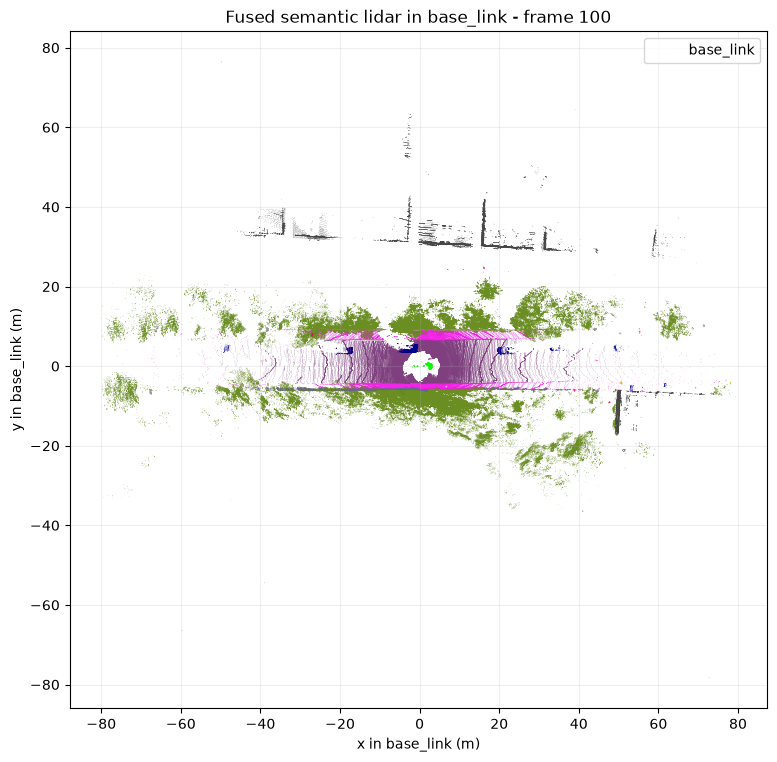

In [12]:
if len(semantic_frames):
    keep = (np.abs(fused.xyz[:, 0]) < 80) & (np.abs(fused.xyz[:, 1]) < 80)
    plt.figure(figsize=(9, 9))
    plt.scatter(
        fused.xyz[keep, 0],
        fused.xyz[keep, 1],
        s=0.1,
        c=fused.colors()[keep],
        linewidths=0,
    )
    plt.scatter([0], [0], c="white", s=30, marker="x", label="base_link")
    plt.gca().set_aspect("equal")
    plt.xlabel("x in base_link (m)")
    plt.ylabel("y in base_link (m)")
    plt.title(f"Fused semantic lidar in base_link - frame {fusion_frame.frame_index}")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## 7. Accumulate a Scene Using Ego Poses

Each sample contains `odom_from_base` as an ego pose. To accumulate a scene, transform points from sensor frame to `base_link`, then from `base_link` to odom using `frame.load_ego_pose()`. The example below accumulates `top_left` over a subset of frames for speed.

In [13]:
accumulated = None
if not lidar_keyframes_installed:
    print("Skipped: lidar_motion_compensated_keyframes is required.")
else:
    accum_scene = scene
    accumulated = accum_scene.accumulate_lidar(
        "top_left",
        stage="motion_compensated",
        step=5,
        max_frames=40,
        stride=1,
        target_frame="odom",
    )
    print(f"Accumulated scene: {accum_scene.scene_id}")
    print(f"Accumulated points in {accumulated.frame}: {accumulated.xyz.shape}")
    print(f"Accumulated fields: {accumulated.field_names}")
    print(f"Frames used: {np.unique(accumulated.frame_index)}")

Accumulated scene: 2026-06-03-09-57-03|98
Accumulated points in odom: (3092778, 3)
Accumulated fields: ('x', 'y', 'z', 't', 'reflectivity', 'ring', 'range')
Frames used: [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195]


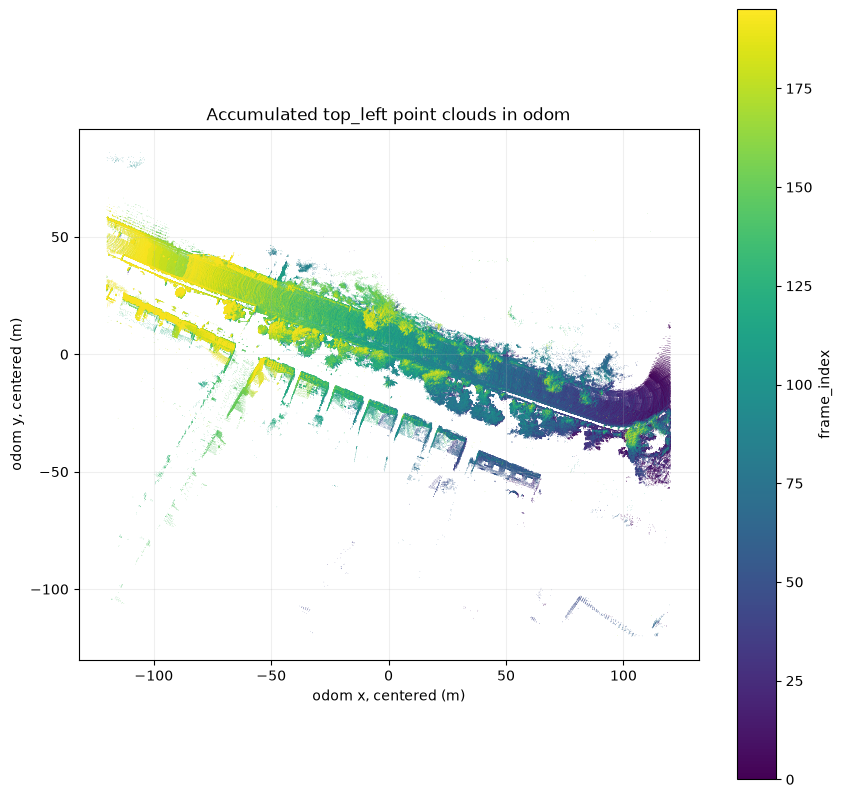

In [14]:
if accumulated is not None and len(accumulated):
    origin = accumulated.xyz[:, :2].mean(axis=0)
    centered_xy = accumulated.xyz[:, :2] - origin
    keep = (np.abs(centered_xy[:, 0]) < 120) & (np.abs(centered_xy[:, 1]) < 120)

    plt.figure(figsize=(10, 10))
    plt.scatter(
        centered_xy[keep, 0],
        centered_xy[keep, 1],
        s=0.1,
        c=accumulated.frame_index[keep],
        cmap="viridis",
        linewidths=0,
    )
    plt.gca().set_aspect("equal")
    plt.xlabel("odom x, centered (m)")
    plt.ylabel("odom y, centered (m)")
    plt.title(f"Accumulated {accumulated.sensor_id} point clouds in odom")
    plt.colorbar(label="frame_index")
    plt.grid(True, alpha=0.2)
    plt.show()